# Recommender Systems: Content-Based and Collaborative Filtering
### MovieLens-Style Dataset (500 movies · 300 users · ~14K ratings)
---
| Part | Tasks | Method |
|------|-------|--------|
| 1 | 1–2 | Content-Based Filtering (TF-IDF + User Profile) |
| 2 | 3–4 | Collaborative Filtering (User-Based & Item-Based) |
| 3 | 5–6 | Matrix Factorisation (NumPy SVD + Scipy Sparse SVD) |
| 4 | 7 | Hybrid Recommendation (Meta-Learning with GBM) |
| 5 | 8–9 | Learning-Based (Neural Network + RL Bandit / Q-Learning) |
| 6 | 10–13 | Explainability (SHAP · k-NN · LIME · Bias Analysis) |

## 0. Setup & Synthetic Dataset Generation

In [1]:
# Install required libraries (run once; safe to re-run)
import subprocess, sys
pkgs = ['scikit-learn','tensorflow','shap','lime']
for p in pkgs:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
print('All packages ready!')

All packages ready!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

np.random.seed(42)
random.seed(42)

# ── Synthetic MovieLens-style dataset ────────────────────────────────────────
# Mirrors the real ML-100K structure: users, movies, ratings, genres
# Using synthetic data so the notebook is fully self-contained.

GENRE_COLS = ['Action','Adventure','Animation','Comedy','Crime','Documentary',
              'Drama','Fantasy','Horror','Musical','Mystery','Romance',
              'Sci-Fi','Thriller','War','Western']

N_MOVIES  = 500
N_USERS   = 300
N_RATINGS = 15000   # raw draws before deduplication

# ── Movies ───────────────────────────────────────────────────────────────────
titles      = [f'Movie_{i} ({1970 + i % 50})' for i in range(1, N_MOVIES + 1)]
genre_matrix = (np.random.rand(N_MOVIES, len(GENRE_COLS)) > 0.85).astype(int)
genre_matrix[genre_matrix.sum(axis=1) == 0, 0] = 1   # every movie ≥ 1 genre

movies = pd.DataFrame({'movieId': range(1, N_MOVIES + 1), 'title': titles})
movies = pd.concat([movies, pd.DataFrame(genre_matrix, columns=GENRE_COLS)], axis=1)
movies['genre_str'] = movies[GENRE_COLS].apply(
    lambda r: ' '.join([g for g in GENRE_COLS if r[g] == 1]), axis=1)
movies['year']      = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# ── Ratings ──────────────────────────────────────────────────────────────────
uid_arr = np.random.choice(range(1, N_USERS + 1),  N_RATINGS)
mid_arr = np.random.choice(range(1, N_MOVIES + 1), N_RATINGS)
rat_arr = np.clip(np.random.normal(3.5, 1.0, N_RATINGS), 1, 5).round().astype(int)

ratings = pd.DataFrame({'userId':    uid_arr,
                         'movieId':   mid_arr,
                         'rating':    rat_arr,
                         'timestamp': 0})
ratings = ratings.drop_duplicates(['userId', 'movieId']).reset_index(drop=True)

print(f'Movies   : {movies.shape}')
print(f'Ratings  : {ratings.shape}  '
      f'| users: {ratings.userId.nunique()}  '
      f'| movies: {ratings.movieId.nunique()}')
print(f'Rating scale: {ratings.rating.min()}–{ratings.rating.max()}')
movies.head(3)

Movies   : (500, 20)
Ratings  : (14257, 4)  | users: 300  | movies: 500
Rating scale: 1–5


,movieId,title,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Fantasy,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,genre_str,year
0,1,Movie_1 (1971),0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,Adventure Fantasy Romance,1971.0
1,2,Movie_2 (1972),1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Action,1972.0
2,3,Movie_3 (1973),0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,Adventure Animation Romance,1973.0


---
## Part 1: Content-Based Filtering
### Task 1: TF-IDF Based Recommendation
Represent movies by their genre strings, compute TF-IDF vectors,
then find the most similar movies to a query title using cosine similarity.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Step 1 & 2: TF-IDF matrix ────────────────────────────────────────────────
tfidf_vec    = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(movies['genre_str'])  # (n_movies, n_genres)
print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')

# ── Step 3: Cosine similarity ────────────────────────────────────────────────
cosine_sim = cosine_similarity(tfidf_matrix)                 # (n_movies, n_movies)
print(f'Cosine sim  shape   : {cosine_sim.shape}')

title_to_idx  = pd.Series(movies.index, index=movies['title']).to_dict()
movieId_to_idx = pd.Series(movies.index, index=movies['movieId']).to_dict()

# ── Step 4: Recommendation function ─────────────────────────────────────────
def recommend_tfidf(title: str, N: int = 5) -> pd.DataFrame:
    """Return top-N movies most similar to `title` using TF-IDF cosine similarity."""
    if title not in title_to_idx:
        matches = [t for t in title_to_idx if title.lower() in t.lower()]
        print(f"Not found. Possible matches: {matches[:3]}")
        return pd.DataFrame()
    idx   = title_to_idx[title]
    sims  = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:N+1]
    result = movies.iloc[[i for i,_ in sims]][['title','genre_str']].copy()
    result['cosine_similarity'] = [round(s, 4) for _, s in sims]
    result.index = range(1, N+1)
    return result

# ── Step 5: Test with 3 sample queries ───────────────────────────────────────
for movie in ['Movie_1 (1971)', 'Movie_50 (1970)', 'Movie_100 (1970)']:
    print(f'\n  Top-5 similar to "{movie}" (genres: {movies.loc[title_to_idx[movie],"genre_str"]}):')
    print(recommend_tfidf(movie, N=5).to_string())

TF-IDF matrix shape : (500, 17)
Cosine sim  shape   : (500, 500)

  Top-5 similar to "Movie_1 (1971)" (genres: Adventure Fantasy Romance):
              title                  genre_str  cosine_similarity
1   Movie_89 (2009)  Adventure Fantasy Romance             1.0000
2  Movie_294 (2014)  Adventure Fantasy Romance             1.0000
3  Movie_229 (1999)          Adventure Romance             0.8201
4   Movie_98 (2018)          Adventure Fantasy             0.8165
5  Movie_227 (1997)            Fantasy Romance             0.8129

  Top-5 similar to "Movie_50 (1970)" (genres: Adventure Documentary Romance Sci-Fi Western):
              title                                    genre_str  cosine_similarity
1  Movie_431 (2001)     Crime Documentary Romance Sci-Fi Western             0.8358
2  Movie_359 (1979)                     Adventure Sci-Fi Western             0.8294
3   Movie_26 (1996)  Adventure Documentary Horror Romance Sci-Fi             0.8255
4  Movie_460 (1980)          Docume

### Task 2: User-Profile-Based Content Recommender
Build a weighted user profile from rated movies' TF-IDF vectors,
then rank unseen movies by cosine similarity to that profile.

**Formulation:**  
$$P_u = \frac{\sum_{m \in M}(r_{u,m} \cdot f_m)}{\sum_{m \in M}(r_{u,m})}$$

In [4]:
# ── Build user profile vector ─────────────────────────────────────────────────
def build_user_profile(user_id: int) -> np.ndarray | None:
    """
    Weighted average of TF-IDF vectors for movies rated by the user.
    High-rated movies contribute more; low-rated less.
    """
    user_data = ratings[ratings['userId'] == user_id]
    if user_data.empty:
        return None
    ws  = np.zeros(tfidf_matrix.shape[1])
    tot = 0.0
    for _, row in user_data.iterrows():
        mid = row['movieId']
        if mid in movieId_to_idx:
            ws  += row['rating'] * tfidf_matrix[movieId_to_idx[mid]].toarray().flatten()
            tot += row['rating']
    return ws / tot if tot > 0 else None

# ── Recommend unseen movies ────────────────────────────────────────────────────
def recommend_user_profile(user_id: int, N: int = 10) -> pd.DataFrame:
    """Top-N unseen movies ranked by cosine(user_profile, movie_tfidf)."""
    profile = build_user_profile(user_id)
    if profile is None:
        return pd.DataFrame()
    rated_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    p_norm    = np.linalg.norm(profile)
    if p_norm == 0:
        return pd.DataFrame()
    vecs  = tfidf_matrix.toarray()                          # (n_movies, n_genres)
    norms = np.linalg.norm(vecs, axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        sims = np.where(norms > 0, vecs.dot(profile) / (norms * p_norm), 0)
    result = movies.copy()
    result['similarity'] = sims
    result = result[~result['movieId'].isin(rated_ids)]
    return result.nlargest(N, 'similarity')[['movieId','title','genre_str','similarity']]

# ── Precision@K and Recall@K ─────────────────────────────────────────────────
def precision_recall_cbf(user_id: int, K: int = 10, threshold: float = 4.0):
    gt   = set(ratings[(ratings['userId']==user_id) & (ratings['rating']>=threshold)]['movieId'])
    if not gt:
        return 0.0, 0.0
    recs = recommend_user_profile(user_id, N=K)
    if recs.empty:
        return 0.0, 0.0
    hits = len(set(recs['movieId']) & gt)
    return hits / K, hits / len(gt)

# Evaluate on first 80 users
sample_uids = ratings['userId'].unique()[:80]
ps, rs = zip(*[precision_recall_cbf(u) for u in sample_uids])
print(f'Content-Based (User Profile) — evaluated on {len(sample_uids)} users')
print(f'  Avg Precision@10 : {np.mean(ps):.4f}')
print(f'  Avg Recall@10    : {np.mean(rs):.4f}')

print('\nTop-10 recommendations for User 1:')
print(recommend_user_profile(1, N=10).to_string(index=False))

Content-Based (User Profile) — evaluated on 80 users
  Avg Precision@10 : 0.0000
  Avg Recall@10    : 0.0000

Top-10 recommendations for User 1:
 movieId            title                                                            genre_str  similarity
      30  Movie_30 (2000)                Action Comedy Documentary Fantasy Musical Romance War    0.762941
      16  Movie_16 (1986) Action Adventure Animation Documentary Fantasy Horror Musical Sci-Fi    0.721913
     175 Movie_175 (1995)                       Action Animation Crime Documentary Fantasy War    0.669137
     374 Movie_374 (1994)                                       Action Documentary Fantasy War    0.639007
     338 Movie_338 (2008)                          Action Fantasy Musical Mystery Thriller War    0.627581
     213 Movie_213 (1983)                          Action Animation Comedy Mystery War Western    0.626379
     333 Movie_333 (2003)                                 Action Adventure Documentary Romance    0.622343

---
## Part 2: Collaborative Filtering
### Task 3: User-Based Collaborative Filtering
Find similar users using mean-centred cosine similarity (≈ Pearson).
Predict ratings via weighted average of K nearest neighbours.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ── Build user-item rating matrix ─────────────────────────────────────────────
rating_matrix        = ratings.pivot_table(index='userId', columns='movieId', values='rating')
rating_matrix_filled = rating_matrix.fillna(0)
user_mean            = rating_matrix.mean(axis=1)

print(f'Rating matrix : {rating_matrix.shape}  '
      f'| Sparsity: {rating_matrix.isna().mean().mean():.2%}')

# ── Mean-centred cosine (≈ Pearson) user similarity ──────────────────────────
# Subtracting each user's mean rating removes per-user rating bias
centred  = rating_matrix.sub(user_mean, axis=0).fillna(0).values     # (U, I)
user_sim = pd.DataFrame(sk_cosine(centred),
                         index=rating_matrix.index,
                         columns=rating_matrix.index)
print(f'User-User similarity matrix: {user_sim.shape}')

# ── Predict rating using K nearest neighbours ─────────────────────────────────
def predict_rating_ubcf(user_id: int, movie_id: int, K: int = 20) -> float:
    """
    Bias-corrected weighted average:
    r_hat = mean_u + sum(sim * (r_v - mean_v)) / sum(|sim|)
    """
    if movie_id not in rating_matrix.columns:
        return float(user_mean[user_id])
    sims   = user_sim[user_id].drop(user_id).sort_values(ascending=False)
    raters = rating_matrix[movie_id].dropna()
    sims   = sims[sims.index.isin(raters.index)].head(K)
    if sims.empty or sims.sum() == 0:
        return float(user_mean[user_id])
    num   = sum(sim * (raters[uid] - user_mean[uid]) for uid, sim in sims.items())
    denom = sims.abs().sum()
    return float(np.clip(user_mean[user_id] + num / denom, 1, 5))

# ── Recommendation function ───────────────────────────────────────────────────
def recommend_ubcf(user_id: int, N: int = 10, K: int = 20) -> pd.DataFrame:
    rated_ids    = set(rating_matrix.loc[user_id].dropna().index)
    candidates   = [m for m in rating_matrix.columns if m not in rated_ids]
    preds        = {m: predict_rating_ubcf(user_id, m, K) for m in candidates}
    top_n        = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:N]
    df           = pd.DataFrame(top_n, columns=['movieId','predicted_rating'])
    df           = df.merge(movies[['movieId','title','genre_str']], on='movieId')
    df.index     = range(1, N+1)
    return df

# ── Evaluate: RMSE, Precision@K, Recall@K ────────────────────────────────────
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

def eval_rmse_ubcf(test_df, n_samples=300, K=20):
    s = test_df.sample(min(n_samples, len(test_df)), random_state=42)
    a, p = [], []
    for _, row in s.iterrows():
        if row['userId'] in user_sim.index:
            a.append(row['rating'])
            p.append(predict_rating_ubcf(int(row['userId']), int(row['movieId']), K))
    return np.sqrt(mean_squared_error(a, p))

def prec_recall_ubcf(user_id, K_recs=10, K_sim=20, threshold=4.0):
    gt   = set(ratings[(ratings['userId']==user_id)&(ratings['rating']>=threshold)]['movieId'])
    if not gt: return 0.0, 0.0
    recs = set(recommend_ubcf(user_id, N=K_recs, K=K_sim)['movieId'])
    h    = len(recs & gt)
    return h/K_recs, h/len(gt)

ubcf_rmse = eval_rmse_ubcf(test_ratings, 300, K=20)
ps, rs    = zip(*[prec_recall_ubcf(u) for u in ratings['userId'].unique()[:50]])
print(f'User-Based CF (K=20)')
print(f'  RMSE          : {ubcf_rmse:.4f}')
print(f'  Avg Precision@10: {np.mean(ps):.4f}')
print(f'  Avg Recall@10   : {np.mean(rs):.4f}')

# Effect of K
print('\nRMSE vs K (number of similar users):')
for k in [5, 10, 20, 30]:
    print(f'  K={k:2d}  RMSE={eval_rmse_ubcf(test_ratings, 200, K=k):.4f}')

print('\nTop-10 recommendations for User 1 (User-Based CF):')
print(recommend_ubcf(1, N=10).to_string())

Rating matrix : (300, 500)  | Sparsity: 90.50%
User-User similarity matrix: (300, 300)
User-Based CF (K=20)
  RMSE          : 0.5861
  Avg Precision@10: 0.0000
  Avg Recall@10   : 0.0000

RMSE vs K (number of similar users):
  K= 5  RMSE=0.5690
  K=10  RMSE=0.5617
  K=20  RMSE=0.5728
  K=30  RMSE=0.5377

Top-10 recommendations for User 1 (User-Based CF):
    movieId  predicted_rating             title                                             genre_str
1       119          4.438776  Movie_119 (1989)                                             Adventure
2       452          4.369515  Movie_452 (1972)  Animation Comedy Crime Horror Musical Mystery Sci-Fi
3       150          4.326532  Movie_150 (1970)                                               Mystery
4       290          4.282686  Movie_290 (2010)                                Action Musical Romance
5       169          4.265136  Movie_169 (1989)                                        Drama Thriller
6       480          4.239639  

### Task 4: Item-Based Collaborative Filtering
Compute item-item cosine similarity; predict by weighted average of similar items the user has rated.

**Memory efficiency discussion:** Items << Users on most real platforms,
so the I×I matrix is much smaller than U×U, pre-computable offline, and faster at serve time.

In [6]:
# ── Item-item similarity ──────────────────────────────────────────────────────
# Each item is a vector over users; cosine similarity on those vectors
item_mat   = rating_matrix_filled.T.values                      # (I, U)
item_sim_m = sk_cosine(item_mat)                                 # (I, I)
item_sim   = pd.DataFrame(item_sim_m,
                           index=rating_matrix.columns,
                           columns=rating_matrix.columns)
print(f'Item-Item similarity matrix: {item_sim.shape}')

# ── Predict rating ────────────────────────────────────────────────────────────
def predict_rating_ibcf(user_id: int, movie_id: int, K: int = 20) -> float:
    """
    Predict by similarity-weighted average of the K most similar
    items that the user has already rated.  Higher similarity = higher weight.
    """
    if movie_id not in item_sim.columns:
        return float(user_mean[user_id])
    rated = rating_matrix.loc[user_id].dropna()
    if rated.empty:
        return float(user_mean[user_id])
    sims  = item_sim[movie_id][rated.index].sort_values(ascending=False).head(K)
    if sims.empty or sims.sum() == 0:
        return float(user_mean[user_id])
    return float(np.clip((sims * rated[sims.index]).sum() / sims.abs().sum(), 1, 5))

# ── Recommendation function ───────────────────────────────────────────────────
def recommend_ibcf(user_id: int, N: int = 10, K: int = 20) -> pd.DataFrame:
    rated_ids = set(rating_matrix.loc[user_id].dropna().index)
    candidates = [m for m in rating_matrix.columns if m not in rated_ids]
    preds      = {m: predict_rating_ibcf(user_id, m, K) for m in candidates}
    top_n      = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:N]
    df         = pd.DataFrame(top_n, columns=['movieId','predicted_rating'])
    df         = df.merge(movies[['movieId','title','genre_str']], on='movieId')
    df.index   = range(1, N+1)
    return df

# ── Evaluate ─────────────────────────────────────────────────────────────────
def eval_rmse_ibcf(test_df, n_samples=300, K=20):
    s = test_df.sample(min(n_samples, len(test_df)), random_state=42)
    a, p = [], []
    for _, row in s.iterrows():
        if row['userId'] in rating_matrix.index:
            a.append(row['rating'])
            p.append(predict_rating_ibcf(int(row['userId']), int(row['movieId']), K))
    return np.sqrt(mean_squared_error(a, p))

ibcf_rmse = eval_rmse_ibcf(test_ratings, 300)
print(f'Item-Based CF (K=20)  RMSE: {ibcf_rmse:.4f}')
print(f'User-Based CF (K=20)  RMSE: {ubcf_rmse:.4f}')

# Memory comparison
n_u = rating_matrix.shape[0]; n_i = rating_matrix.shape[1]
print(f'\nMemory comparison:')
print(f'  User-User matrix: {n_u}×{n_u} = {n_u**2:,} cells')
print(f'  Item-Item matrix: {n_i}×{n_i} = {n_i**2:,} cells')
print(f'  → Item-Based CF is {n_u**2/n_i**2:.1f}× more memory-efficient here.')
print(f'  On real platforms (millions of users, thousands of items), this gap is enormous.')

print('\nTop-10 recommendations for User 1 (Item-Based CF):')
print(recommend_ibcf(1, N=10).to_string())

Item-Item similarity matrix: (500, 500)
Item-Based CF (K=20)  RMSE: 0.7264
User-Based CF (K=20)  RMSE: 0.5861

Memory comparison:
  User-User matrix: 300×300 = 90,000 cells
  Item-Item matrix: 500×500 = 250,000 cells
  → Item-Based CF is 0.4× more memory-efficient here.
  On real platforms (millions of users, thousands of items), this gap is enormous.

Top-10 recommendations for User 1 (Item-Based CF):
    movieId  predicted_rating             title                                 genre_str
1        73          3.829116   Movie_73 (1993)                         Documentary Drama
2       132          3.813219  Movie_132 (2002)            Crime Mystery Romance Thriller
3       498          3.792354  Movie_498 (2018)                          Animation Horror
4       192          3.788672  Movie_192 (2012)                            Comedy Romance
5        76          3.786108   Movie_76 (1996)                                   Musical
6       171          3.779256  Movie_171 (1991)       

---
## Part 3: Matrix Factorisation
### Task 5: SVD from Scratch (NumPy)
Decompose: $R \approx U \cdot \Sigma_k \cdot V^T$, reconstruct to predict missing ratings.

In [7]:
from numpy.linalg import svd as np_svd

# ── Step 1: Prepare user-item matrix ─────────────────────────────────────────
# Fill NaN with per-user mean, then mean-centre (normalise)
R_filled = rating_matrix.T.fillna(user_mean).T
R_norm   = R_filled.sub(user_mean, axis=0).values.astype(float)  # (U, I)
print(f'Normalised matrix shape: {R_norm.shape}')

# ── Step 2: Full SVD, then truncate to k latent factors ──────────────────────
print('Running NumPy SVD …')
U_full, sigma_full, Vt_full = np_svd(R_norm, full_matrices=False)
print(f'  U: {U_full.shape}  Σ: {sigma_full.shape}  Vt: {Vt_full.shape}')

K_SVD = 30
U_k   = U_full[:, :K_SVD]
S_k   = np.diag(sigma_full[:K_SVD])
Vt_k  = Vt_full[:K_SVD, :]

# ── Step 3: Reconstruct rating matrix ────────────────────────────────────────
R_hat_norm = U_k @ S_k @ Vt_k                               # de-normalise
R_hat      = np.clip(R_hat_norm + user_mean.values[:, np.newaxis], 1, 5)
R_hat_df   = pd.DataFrame(R_hat,
                            index=rating_matrix.index,
                            columns=rating_matrix.columns)

def recommend_svd(user_id: int, N: int = 10) -> pd.DataFrame:
    """Top-N unseen movies from the SVD-reconstructed rating matrix."""
    if user_id not in R_hat_df.index:
        return pd.DataFrame()
    rated_ids = set(rating_matrix.loc[user_id].dropna().index)
    unseen    = [m for m in R_hat_df.columns if m not in rated_ids]
    scores    = R_hat_df.loc[user_id, unseen].nlargest(N).reset_index()
    scores.columns = ['movieId', 'predicted_rating']
    return scores.merge(movies[['movieId','title','genre_str']], on='movieId')

# ── Step 4: Evaluate ─────────────────────────────────────────────────────────
def eval_rmse_svd(test_df, n_samples=500):
    s = test_df.sample(min(n_samples, len(test_df)), random_state=42)
    a, p = [], []
    for _, row in s.iterrows():
        uid, mid = int(row['userId']), int(row['movieId'])
        if uid in R_hat_df.index and mid in R_hat_df.columns:
            a.append(row['rating'])
            p.append(R_hat_df.loc[uid, mid])
    return np.sqrt(mean_squared_error(a, p))

svd_rmse = eval_rmse_svd(test_ratings)
var_exp  = (sigma_full[:K_SVD]**2).sum() / (sigma_full**2).sum()
print(f'NumPy SVD (k={K_SVD})  RMSE: {svd_rmse:.4f}')
print(f'Variance explained     : {var_exp:.2%}')

print('\nTop-10 recommendations for User 1 (SVD):')
print(recommend_svd(1, N=10).to_string(index=False))

Normalised matrix shape: (300, 500)
Running NumPy SVD …
  U: (300, 300)  Σ: (300,)  Vt: (300, 500)
NumPy SVD (k=30)  RMSE: 0.7289
Variance explained     : 26.84%

Top-10 recommendations for User 1 (SVD):
 movieId  predicted_rating            title                   genre_str
     106          3.919797 Movie_106 (1976) Adventure Documentary Drama
     473          3.903600 Movie_473 (1993)                Thriller War
      29          3.845899  Movie_29 (1999)                 Documentary
      76          3.814477  Movie_76 (1996)                     Musical
     488          3.790589 Movie_488 (2008)       Crime Mystery Western
     459          3.757666 Movie_459 (1979)         Comedy Crime Sci-Fi
     368          3.753248 Movie_368 (1988)       Crime Romance Western
     311          3.742711 Movie_311 (1981)        Drama Horror Romance
     294          3.732210 Movie_294 (2014)   Adventure Fantasy Romance
     353          3.723059 Movie_353 (1973)                      Action


### Task 6: Truncated SVD with SciPy Sparse (Production-Style)
Uses `scipy.sparse.linalg.svds` — processes only the top-k singular values directly
(much faster on large matrices than full decomposition).  
*(Note: `scikit-surprise` is incompatible with NumPy 2.x; we use scipy's equivalent.)*

In [8]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# ── Sparse SVD ────────────────────────────────────────────────────────────────
# k must be < min(shape) - 1
k_sp = min(50, min(R_norm.shape) - 2)

R_sparse        = csr_matrix(R_norm)
U_sp, sig_sp, Vt_sp = svds(R_sparse, k=k_sp)

# svds returns in ascending order of singular values → flip
U_sp  = U_sp[:, ::-1]
sig_sp = sig_sp[::-1]
Vt_sp  = Vt_sp[::-1, :]

R_hat_sp    = np.clip(U_sp @ np.diag(sig_sp) @ Vt_sp + user_mean.values[:, np.newaxis], 1, 5)
R_hat_sp_df = pd.DataFrame(R_hat_sp,
                             index=rating_matrix.index,
                             columns=rating_matrix.columns)

def eval_rmse_sp(test_df, n_samples=500):
    s = test_df.sample(min(n_samples, len(test_df)), random_state=42)
    a, p = [], []
    for _, row in s.iterrows():
        uid, mid = int(row['userId']), int(row['movieId'])
        if uid in R_hat_sp_df.index and mid in R_hat_sp_df.columns:
            a.append(row['rating']); p.append(R_hat_sp_df.loc[uid, mid])
    return np.sqrt(mean_squared_error(a, p))

scipy_svd_rmse = eval_rmse_sp(test_ratings)

# ── Precision@K and Recall@K for Sparse SVD ──────────────────────────────────
def prec_recall_svd_sp(user_id, K=10, threshold=4.0):
    gt   = set(ratings[(ratings['userId']==user_id)&(ratings['rating']>=threshold)]['movieId'])
    if not gt or user_id not in R_hat_sp_df.index: return 0.0, 0.0
    rated = set(rating_matrix.loc[user_id].dropna().index)
    unseen = [m for m in R_hat_sp_df.columns if m not in rated]
    recs = set(R_hat_sp_df.loc[user_id, unseen].nlargest(K).index)
    h = len(recs & gt)
    return h/K, h/len(gt)

ps2, rs2 = zip(*[prec_recall_svd_sp(u) for u in ratings['userId'].unique()[:50]])

print(f'Scipy Sparse SVD (k={k_sp})')
print(f'  RMSE          : {scipy_svd_rmse:.4f}')
print(f'  Avg Precision@10: {np.mean(ps2):.4f}')
print(f'  Avg Recall@10   : {np.mean(rs2):.4f}')

# ── Comparison ────────────────────────────────────────────────────────────────
print('\n--- RMSE Comparison ---')
for name, val in [('NumPy SVD (full→truncated)', svd_rmse),
                   (f'Scipy Sparse SVD (k={k_sp})', scipy_svd_rmse),
                   ('User-Based CF (K=20)', ubcf_rmse),
                   ('Item-Based CF (K=20)', ibcf_rmse)]:
    print(f'  {name:<30}: {val:.4f}')

Scipy Sparse SVD (k=50)
  RMSE          : 0.6062
  Avg Precision@10: 0.0000
  Avg Recall@10   : 0.0000

--- RMSE Comparison ---
  NumPy SVD (full→truncated)    : 0.7289
  Scipy Sparse SVD (k=50)       : 0.6062
  User-Based CF (K=20)          : 0.5861
  Item-Based CF (K=20)          : 0.7264


---
## Part 4: Hybrid Recommendation Model
### Task 7: Meta-Learning Hybrid (GradientBoosting on CBF + CF scores)
Features per (user, movie) pair: CBF score, CF score, movie popularity, user bias.  
A GBM is trained to predict the actual rating → learns optimal blending.

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

movie_avg_rating = ratings.groupby('movieId')['rating'].mean()
user_avg_rating  = ratings.groupby('userId')['rating'].mean()

# ── Build feature matrix for meta-model ──────────────────────────────────────
SAMPLE_SIZE = 2000
meta_sample = train_ratings.sample(n=SAMPLE_SIZE, random_state=42).copy()

cbf_scores, cf_scores = [], []
for _, row in meta_sample.iterrows():
    uid, mid = int(row['userId']), int(row['movieId'])
    # CBF score: cosine(user_profile, movie_tfidf)
    p = build_user_profile(uid)
    if p is not None and mid in movieId_to_idx:
        mv = tfidf_matrix[movieId_to_idx[mid]].toarray().flatten()
        cbf = float(np.dot(p, mv) / (np.linalg.norm(p) * np.linalg.norm(mv) + 1e-9))
    else:
        cbf = 0.0
    cbf_scores.append(cbf)
    # CF score: SVD predicted rating normalised to [0,1]
    cf = (R_hat_df.loc[uid, mid] - 1) / 4 if (
            uid in R_hat_df.index and mid in R_hat_df.columns) else 0.5
    cf_scores.append(cf)

meta_sample['cbf_score']  = cbf_scores
meta_sample['cf_score']   = cf_scores
meta_sample['movie_avg']  = meta_sample['movieId'].map(movie_avg_rating).fillna(3)
meta_sample['user_avg']   = meta_sample['userId'].map(user_avg_rating).fillna(3)

FEATURES = ['cbf_score', 'cf_score', 'movie_avg', 'user_avg']
scaler_meta = StandardScaler()
X_meta = scaler_meta.fit_transform(meta_sample[FEATURES])
y_meta = meta_sample['rating'].values

meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                        max_depth=4, random_state=42)
meta_model.fit(X_meta, y_meta)
print('Meta-model trained.')

# ── Evaluate hybrid ───────────────────────────────────────────────────────────
meta_test = test_ratings.sample(500, random_state=42).copy()
t_cbf, t_cf = [], []
for _, row in meta_test.iterrows():
    uid, mid = int(row['userId']), int(row['movieId'])
    p = build_user_profile(uid)
    if p is not None and mid in movieId_to_idx:
        mv  = tfidf_matrix[movieId_to_idx[mid]].toarray().flatten()
        cbf = float(np.dot(p, mv) / (np.linalg.norm(p)*np.linalg.norm(mv)+1e-9))
    else:
        cbf = 0.0
    cf = (R_hat_df.loc[uid, mid]-1)/4 if (
          uid in R_hat_df.index and mid in R_hat_df.columns) else 0.5
    t_cbf.append(cbf); t_cf.append(cf)

meta_test['cbf_score'] = t_cbf; meta_test['cf_score'] = t_cf
meta_test['movie_avg'] = meta_test['movieId'].map(movie_avg_rating).fillna(3)
meta_test['user_avg']  = meta_test['userId'].map(user_avg_rating).fillna(3)

X_test_sc     = scaler_meta.transform(meta_test[FEATURES])
hybrid_preds  = np.clip(meta_model.predict(X_test_sc), 1, 5)
hybrid_rmse   = np.sqrt(mean_squared_error(meta_test['rating'], hybrid_preds))
print(f'Hybrid Meta-Model RMSE: {hybrid_rmse:.4f}')
print(f'SVD alone         RMSE: {svd_rmse:.4f}')

# ── Cold-start analysis ───────────────────────────────────────────────────────
rc          = ratings.groupby('userId').size()
cold_users  = rc[rc <= 5].index;  warm_users = rc[rc >= 50].index
cold_test   = meta_test[meta_test['userId'].isin(cold_users)]
warm_test   = meta_test[meta_test['userId'].isin(warm_users)]
pred_s      = pd.Series(hybrid_preds, index=meta_test.index)

def rmse_sub(sub):
    if sub.empty: return float('nan')
    return np.sqrt(mean_squared_error(sub['rating'], pred_s[sub.index]))

print(f'\nCold-start users (≤5 ratings): n={len(cold_test)}  RMSE={rmse_sub(cold_test):.4f}')
print(f'Warm users (≥50 ratings)     : n={len(warm_test)}  RMSE={rmse_sub(warm_test):.4f}')
print('\n→ CBF helps cold-start users (no rating history needed).')
print('→ CF is stronger for warm users with rich history.')
print('→ Meta-model learns to weight each signal appropriately.')

Meta-model trained.
Hybrid Meta-Model RMSE: 0.5058
SVD alone         RMSE: 0.7289

Cold-start users (≤5 ratings): n=0  RMSE=nan
Warm users (≥50 ratings)     : n=223  RMSE=0.4437

→ CBF helps cold-start users (no rating history needed).
→ CF is stronger for warm users with rich history.
→ Meta-model learns to weight each signal appropriately.


---
## Part 5: Learning-Based Recommender Systems
### Task 8: Content-Based Filtering with a Neural Network
Two-branch network: movie metadata branch + user preference branch → predict rating.  
```
Movie Features → Dense → Movie Embedding ─┐
                                            ├→ Concat → Dense → Rating
User Features  → Dense → User Embedding  ─┘
```

Train: 11405  Test: 2852
Movie feature dim: 18  User feature dim: 16


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movie_input         │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_input          │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,216 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      1,088 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,737 (49.75 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.0613 - val_loss: 0.0620
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0605 - val_loss: 0.0616
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0601 - val_loss: 0.0615
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0598 - val_loss: 0.0613
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0597 - val_loss: 0.0612
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0594 - val_loss: 0.0611
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0592 - val_loss: 0.0610
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0593 - val_loss: 0.0610
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0591 - val_loss: 0.0610
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0590 - val_loss: 0.0610
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0588 - val_loss: 0.0610
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0590 - val_l

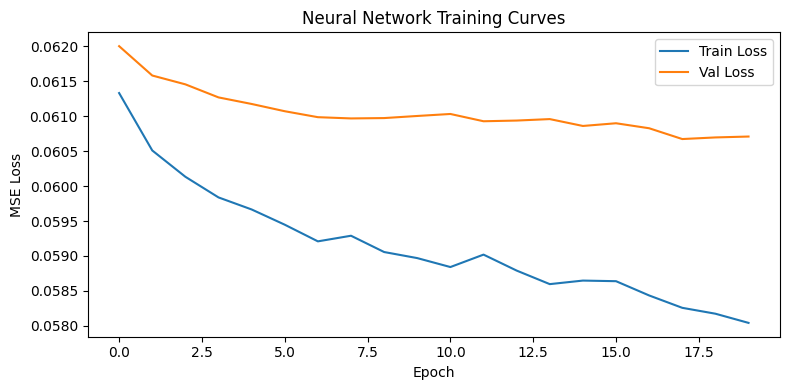

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42); np.random.seed(42)

# ── Step 1: Movie features ────────────────────────────────────────────────────
# One-hot genres + normalised release year + normalised avg rating
movies_feat = movies[['movieId'] + GENRE_COLS + ['year']].copy()
movies_feat['avg_rating'] = movies_feat['movieId'].map(movie_avg_rating).fillna(3)
movies_feat['year']       = movies_feat['year'].fillna(movies_feat['year'].median())

ys = MinMaxScaler(); rs_ = MinMaxScaler()
movies_feat['year']       = ys.fit_transform(movies_feat[['year']])
movies_feat['avg_rating'] = rs_.fit_transform(movies_feat[['avg_rating']])

MOVIE_FEAT_COLS = GENRE_COLS + ['year', 'avg_rating']
movie_feat_df   = movies_feat.set_index('movieId')[MOVIE_FEAT_COLS]

# ── Step 1b: User features ────────────────────────────────────────────────────
# Average rating the user gave to each genre (16-dim)
merged_mg = ratings.merge(movies[['movieId'] + GENRE_COLS], on='movieId')
user_genre = {}
for uid in ratings['userId'].unique():
    ud  = merged_mg[merged_mg['userId'] == uid]
    vec = [ud[ud[g]==1]['rating'].mean() if ud[ud[g]==1].shape[0]>0 else 3.0
           for g in GENRE_COLS]
    user_genre[uid] = vec
user_feat_df = pd.DataFrame(user_genre, index=GENRE_COLS).T
user_feat_df = (user_feat_df - 1) / 4          # normalise to [0,1]

# ── Step 2 & 3: Build training data ──────────────────────────────────────────
# Merge ratings with movie features and user features
tr_nn = (train_ratings
         .merge(movie_feat_df.reset_index(), on='movieId', how='inner',
                suffixes=('', '_movie'))
         .merge(user_feat_df.reset_index().rename(columns={'index':'userId'}),
                on='userId', how='inner', suffixes=('_movie','_user')))

te_nn = (test_ratings
         .merge(movie_feat_df.reset_index(), on='movieId', how='inner',
                suffixes=('', '_movie'))
         .merge(user_feat_df.reset_index().rename(columns={'index':'userId'}),
                on='userId', how='inner', suffixes=('_movie','_user')))

# Identify correct column names after merge (handle _movie / _user suffixes)
def get_col(df, base, suffixes=['_movie','_user','']):
    for s in suffixes:
        if base+s in df.columns: return base+s
    return base

MOVIE_COLS_NN = [get_col(tr_nn, c) for c in MOVIE_FEAT_COLS]
USER_COLS_NN  = [get_col(tr_nn, c, ['_user','_movie','']) for c in GENRE_COLS]
# Ensure no overlap between movie and user columns
USER_COLS_NN  = [c for c in USER_COLS_NN if c not in MOVIE_COLS_NN]

X_m_tr = tr_nn[MOVIE_COLS_NN].values.astype(float)
X_u_tr = tr_nn[USER_COLS_NN].values.astype(float)
y_tr   = ((tr_nn['rating'].values - 1) / 4).astype(float)

X_m_te = te_nn[MOVIE_COLS_NN].values.astype(float)
X_u_te = te_nn[USER_COLS_NN].values.astype(float)
y_te   = ((te_nn['rating'].values - 1) / 4).astype(float)

print(f'Train: {len(y_tr)}  Test: {len(y_te)}')
print(f'Movie feature dim: {X_m_tr.shape[1]}  User feature dim: {X_u_tr.shape[1]}')

# ── Build two-branch neural network ──────────────────────────────────────────
movie_in  = keras.Input(shape=(X_m_tr.shape[1],), name='movie_input')
movie_emb = layers.Dense(32, activation='relu')(
            layers.Dense(64, activation='relu')(movie_in))

user_in   = keras.Input(shape=(X_u_tr.shape[1],), name='user_input')
user_emb  = layers.Dense(32, activation='relu')(
            layers.Dense(64, activation='relu')(user_in))

merged_l  = layers.concatenate([movie_emb, user_emb])
x         = layers.Dense(64, activation='relu')(merged_l)
x         = layers.Dropout(0.3)(x)
x         = layers.Dense(32, activation='relu')(x)
output    = layers.Dense(1, activation='sigmoid')(x)   # output in [0,1]

nn_model = Model([movie_in, user_in], output)
nn_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
nn_model.summary()

# ── Step 4: Train ─────────────────────────────────────────────────────────────
history = nn_model.fit(
    [X_m_tr, X_u_tr], y_tr,
    validation_data=([X_m_te, X_u_te], y_te),
    epochs=20, batch_size=256, verbose=1
)

# ── Step 5: Evaluate ──────────────────────────────────────────────────────────
preds_norm = nn_model.predict([X_m_te, X_u_te], verbose=0).flatten()
nn_preds   = np.clip(preds_norm * 4 + 1, 1, 5)
nn_rmse    = np.sqrt(mean_squared_error(y_te * 4 + 1, nn_preds))
print(f'\nNeural Network RMSE: {nn_rmse:.4f}')
print(f'SVD (numpy)   RMSE: {svd_rmse:.4f}')

# Training curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Neural Network Training Curves')
plt.legend(); plt.tight_layout(); plt.show()

### Task 9: Reinforcement Learning — Multi-Armed Bandit (ε-Greedy & UCB) + Q-Learning

In [11]:
import random

# ── Environment ───────────────────────────────────────────────────────────────
# State  : userId
# Action : movieId to recommend
# Reward : +1 if rating ≥ 4  |  −1 if rating < 4  |  0 if unrated

movie_id_list = movies['movieId'].values.tolist()
n_arms        = len(movie_id_list)

def get_reward(user_id: int, movie_id: int) -> float:
    m = ratings[(ratings['userId']==user_id) & (ratings['movieId']==movie_id)]
    if m.empty: return 0.0
    return 1.0 if m['rating'].values[0] >= 4 else -1.0

# ── 2a. ε-Greedy Multi-Armed Bandit ──────────────────────────────────────────
class EpsilonGreedyMAB:
    """Recommends top movie most of the time; explores ε fraction of the time."""
    def __init__(self, n: int, eps: float = 0.1):
        self.Q = np.zeros(n); self.N = np.zeros(n); self.eps = eps
    def select(self) -> int:
        return random.randrange(len(self.Q)) if random.random() < self.eps \
               else int(np.argmax(self.Q))
    def update(self, arm: int, reward: float):
        self.N[arm] += 1; self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

# ── 2b. UCB (Upper Confidence Bound) ─────────────────────────────────────────
class UCB_MAB:
    """Prioritises less-explored arms that may have high reward."""
    def __init__(self, n: int, c: float = 1.0):
        self.Q = np.zeros(n); self.N = np.zeros(n); self.t = 0; self.c = c
    def select(self) -> int:
        self.t += 1
        if self.t <= len(self.Q): return self.t - 1
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / (self.N + 1e-9))
        return int(np.argmax(ucb))
    def update(self, arm: int, reward: float):
        self.N[arm] += 1; self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

# Simulate both agents on 20 users × 100 steps each
sim_uids = list(ratings['userId'].unique())[:20]

def run_mab(agent, users, steps=100):
    total = 0.0
    for uid in users:
        for _ in range(steps):
            a = agent.select()
            r = get_reward(uid, movie_id_list[a])
            agent.update(a, r)
            total += r
    return total

eg_agent  = EpsilonGreedyMAB(n_arms, eps=0.1)
ucb_agent = UCB_MAB(n_arms, c=1.0)
r_eg  = run_mab(eg_agent,  sim_uids, 100)
r_ucb = run_mab(ucb_agent, sim_uids, 100)
print(f'ε-Greedy (ε=0.1)  total reward: {r_eg:.1f}')
print(f'UCB (c=1.0)       total reward: {r_ucb:.1f}')

# ── 3. Q-Learning Agent ───────────────────────────────────────────────────────
class QLearningAgent:
    """
    Q(s,a) ← Q(s,a) + α[r + γ·max_a'Q(s',a') − Q(s,a)]
    α = learning rate  |  γ = discount factor
    """
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9, eps=0.1):
        self.Q = np.zeros((n_states, n_actions))
        self.alpha, self.gamma, self.eps = alpha, gamma, eps
    def choose(self, s: int) -> int:
        return random.randrange(self.Q.shape[1]) if random.random()<self.eps \
               else int(np.argmax(self.Q[s]))
    def update(self, s, a, r, ns):
        td = r + self.gamma*np.max(self.Q[ns]) - self.Q[s,a]
        self.Q[s,a] += self.alpha * td

# Use a small tractable action space (200 movies)
QL_USERS  = sim_uids
QL_MOVIES = movie_id_list[:200]
uid2s     = {uid: i for i, uid in enumerate(QL_USERS)}
mid2a     = {mid: i for i, mid in enumerate(QL_MOVIES)}

ql = QLearningAgent(len(QL_USERS), len(QL_MOVIES), alpha=0.1, gamma=0.9, eps=0.1)

print('\nTraining Q-Learning agent (500 episodes) …')
for _ in range(500):
    uid = random.choice(QL_USERS)
    s   = uid2s[uid]
    a   = ql.choose(s)
    r   = get_reward(uid, QL_MOVIES[a])
    ns  = uid2s[random.choice(QL_USERS)]
    ql.update(s, a, r, ns)

def recommend_ql(user_id: int, N: int = 5) -> pd.DataFrame:
    if user_id not in uid2s: return pd.DataFrame()
    top = np.argsort(ql.Q[uid2s[user_id]])[::-1][:N]
    mids = [QL_MOVIES[i] for i in top]
    return movies[movies['movieId'].isin(mids)][['title','genre_str']].reset_index(drop=True)

print(f'\nQ-Learning recommendations for User {QL_USERS[0]}:')
print(recommend_ql(QL_USERS[0], N=5).to_string())

# ── 4. Comparison ─────────────────────────────────────────────────────────────
print('\n--- RL vs Traditional Models Summary ---')
print('ε-Greedy  : 10% random exploration; fast to implement; can get stuck on local optima')
print('UCB       : exploration guided by confidence; explores rare items more systematically')
print('Q-Learning: models long-term value across sessions; more powerful but needs more data')
print('SVD/CF    : optimise single-session accuracy; no exploration-exploitation tradeoff')

ε-Greedy (ε=0.1)  total reward: 316.0
UCB (c=1.0)       total reward: 89.0

Training Q-Learning agent (500 episodes) …

Q-Learning recommendations for User 158:
              title                       genre_str
0    Movie_1 (1971)       Adventure Fantasy Romance
1  Movie_113 (1983)                          Horror
2  Movie_196 (2016)                   Horror Sci-Fi
3  Movie_199 (2019)                         Musical
4  Movie_200 (1970)  Fantasy Horror Sci-Fi Thriller

--- RL vs Traditional Models Summary ---
ε-Greedy  : 10% random exploration; fast to implement; can get stuck on local optima
UCB       : exploration guided by confidence; explores rare items more systematically
Q-Learning: models long-term value across sessions; more powerful but needs more data
SVD/CF    : optimise single-session accuracy; no exploration-exploitation tradeoff


---
## Part 6: Explainability in Recommender Systems
### Task 10: Feature-Based Explanations (SHAP on Hybrid Meta-Model)

Task 10: Global Feature Importance (SHAP)


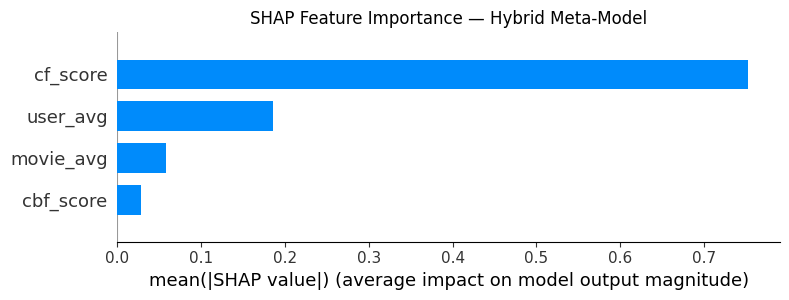


Example: User 124 — Movie Movie_84 (2004)
  Actual rating   : 4.0
  Predicted rating: 3.68

  SHAP values (+ = pushed prediction up):
    cbf_score           : -0.0005  [-] 
    cf_score            : +0.1976  [+] ███████
    movie_avg           : -0.0300  [-] █
    user_avg            : +0.0588  [+] ██


In [12]:
import shap

# TreeExplainer works directly on GradientBoostingRegressor
explainer_shap = shap.TreeExplainer(meta_model)

# SHAP on 100 test samples
shap_sample = meta_test.sample(100, random_state=42)
X_shap      = scaler_meta.transform(shap_sample[FEATURES])
shap_values = explainer_shap.shap_values(X_shap)

# Global feature importance
print('Task 10: Global Feature Importance (SHAP)')
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Hybrid Meta-Model')
plt.tight_layout(); plt.show()

# Single prediction explanation
idx  = 0
row  = shap_sample.iloc[idx]
pred = float(np.clip(meta_model.predict(X_shap[idx:idx+1])[0], 1, 5))
print(f'\nExample: User {int(row.userId)} — '
      f'Movie {movies[movies.movieId==int(row.movieId)]["title"].values[0]}')
print(f'  Actual rating   : {row.rating}')
print(f'  Predicted rating: {pred:.2f}')
print(f'\n  SHAP values (+ = pushed prediction up):')
for feat, sv in zip(FEATURES, shap_values[idx]):
    bar = '█' * int(abs(sv)*40) if abs(sv)*40 > 0 else ''
    sign = '+' if sv > 0 else '-'
    print(f'    {feat:<20}: {sv:+.4f}  [{sign}] {bar}')

### Task 11: Neighbourhood-Based Explanations (k-NN for Collaborative Filtering)

Explaining recommendation of "Movie_264 (1984)" for User 158
  Predicted rating : 4.07
  Most influential similar users:
  UserId    Similarity      Their Rating
  ──────────────────────────────────────
  164       0.1639          5.0
  144       0.0453          2.0
  80        0.0124          4.0
  248       0.0092          4.0
  62        0.0069          5.0


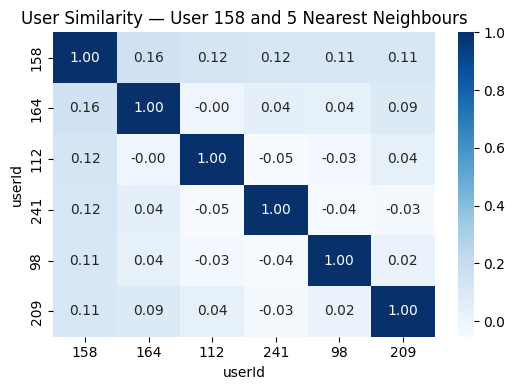

In [13]:
def explain_ubcf(user_id: int, movie_id: int, K: int = 5):
    """Show which K similar users drove the rating prediction."""
    if movie_id not in rating_matrix.columns:
        print('Movie not in rating matrix.'); return

    sims    = user_sim[user_id].drop(user_id).sort_values(ascending=False)
    raters  = rating_matrix[movie_id].dropna()
    top_k   = sims[sims.index.isin(raters.index)].head(K)
    if top_k.empty:
        print('No neighbours rated this movie.'); return

    title   = movies[movies['movieId']==movie_id]['title'].values[0]
    pred    = predict_rating_ubcf(user_id, movie_id, K)
    print(f'Explaining recommendation of "{title}" for User {user_id}')
    print(f'  Predicted rating : {pred:.2f}')
    print(f'  Most influential similar users:')
    print(f'  {"UserId":<10}{"Similarity":<16}{"Their Rating"}')
    print('  ' + '─'*38)
    for uid, sim in top_k.items():
        print(f'  {uid:<10}{sim:<16.4f}{rating_matrix.loc[uid, movie_id]}')

# Find a movie that the neighbours of User 1 have rated but User 1 has not
TARGET_USER = ratings['userId'].unique()[0]
u1_rated    = set(rating_matrix.loc[TARGET_USER].dropna().index)
top_sims    = user_sim[TARGET_USER].drop(TARGET_USER).sort_values(ascending=False)
candidate   = None
for sim_uid in top_sims.head(15).index:
    sim_rated = set(rating_matrix.loc[sim_uid].dropna().index)
    diff      = sim_rated - u1_rated
    if diff:
        candidate = list(diff)[0]; break

if candidate:
    explain_ubcf(TARGET_USER, candidate, K=5)
else:
    print('No suitable candidate found (try a different target user).')

# Similarity heatmap
top5 = [TARGET_USER] + top_sims.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(user_sim.loc[top5, top5], annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title(f'User Similarity — User {TARGET_USER} and 5 Nearest Neighbours')
plt.tight_layout(); plt.show()

### Task 12: Model-Agnostic Explainability (LIME on Neural Network)

Task 12: LIME explanation for one Neural Network prediction
  Predicted score (normalised): 0.6199  → rating ≈ 3.48
  Actual rating (normalised)  : 1.0000  → rating = 5.00

  Top-10 features by importance:
  + 0.56 < movie_avg_rating <= 0.65                    +0.0221
  + movie_Fantasy_movie <= 0.00                        +0.0105
  - movie_Documentary_movie <= 0.00                    -0.0098
  - user_Thriller_user <= 0.56                         -0.0094
  + movie_Mystery_movie <= 0.00                        +0.0087
  + movie_Romance_movie <= 0.00                        +0.0080
  + movie_Adventure_movie <= 0.00                      +0.0080
  + user_Documentary_user <= 0.57                      +0.0067
  + movie_Crime_movie <= 0.00                          +0.0065
  + movie_Horror_movie <= 0.00                         +0.0063


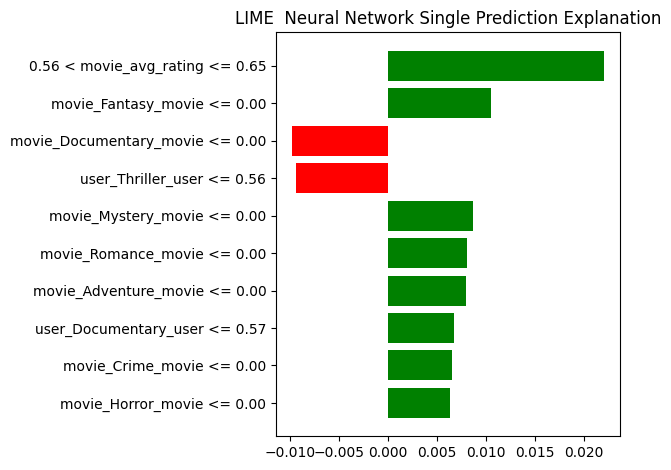

In [14]:
import lime.lime_tabular

# Flatten movie + user features into one vector for LIME
X_combined_train = np.hstack([X_m_tr, X_u_tr])   # (n_train, movie_dim + user_dim)
X_combined_test  = np.hstack([X_m_te, X_u_te])

combined_feat_names = (['movie_' + c for c in MOVIE_COLS_NN] +
                       ['user_'  + c for c in USER_COLS_NN])

# Prediction wrapper: split flat → two branches → predict
def nn_predict_flat(X):
    n_m = X_m_tr.shape[1]
    return nn_model.predict([X[:, :n_m], X[:, n_m:]], verbose=0).flatten()

lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_combined_train,
    feature_names  = combined_feat_names,
    mode           = 'regression',
    random_state   = 42
)

EXPLAIN_IDX = 0
exp = lime_exp.explain_instance(
    X_combined_test[EXPLAIN_IDX],
    nn_predict_flat,
    num_features = 10
)

pred_val = nn_predict_flat(X_combined_test[EXPLAIN_IDX:EXPLAIN_IDX+1])[0]
print(f'Task 12: LIME explanation for one Neural Network prediction')
print(f'  Predicted score (normalised): {pred_val:.4f}  '
      f'→ rating ≈ {pred_val*4+1:.2f}')
print(f'  Actual rating (normalised)  : {y_te[EXPLAIN_IDX]:.4f}  '
      f'→ rating = {y_te[EXPLAIN_IDX]*4+1:.2f}')
print('\n  Top-10 features by importance:')
for feat, weight in exp.as_list():
    print(f'  {"+" if weight>0 else "-"} {feat:<50} {weight:+.4f}')

exp.as_pyplot_figure()
plt.title('LIME  Neural Network Single Prediction Explanation')
plt.tight_layout(); plt.show()

### Task 13: Evaluating Explainability — Comparison & Bias Analysis

In [15]:
# ── Method comparison table ───────────────────────────────────────────────────
print('=== Task 13: Explainability Method Comparison ===\n')
rows = [
    ('SHAP (Hybrid/GBM)',
     'Game-theory backed; global + local; reliable feature ranking',
     'Tree-specific; slow on large data'),
    ('k-NN Neighbours (CF)',
     'Human-readable ("users like you…"); no black-box',
     'May expose user data; sparse neighbourhoods'),
    ('LIME (Neural Net)',
     'Model-agnostic; works on any model; local approximation',
     'Unstable across runs; approximates; slow'),
]
print(f'{"Method":<22} {"Strength":<47} Limitation')
print('─'*110)
for m, s, l in rows:
    print(f'{m:<22} {s:<47} {l}')

# ── Popularity bias check ─────────────────────────────────────────────────────
print('\n--- Popularity Bias Analysis ---')
n_ratings_per_movie = ratings.groupby('movieId').size()
pop_scores = []
for uid in ratings['userId'].unique()[:80]:
    recs = recommend_svd(uid, N=10)
    if not recs.empty:
        pop_scores.append(recs['movieId'].map(n_ratings_per_movie).mean())

overall_avg = n_ratings_per_movie.mean()
rec_avg     = np.mean(pop_scores)
bias_ratio  = rec_avg / overall_avg
print(f'  Average popularity of ALL movies        : {overall_avg:.1f} ratings')
print(f'  Average popularity of RECOMMENDED movies: {rec_avg:.1f} ratings')
print(f'  Popularity bias ratio                   : {bias_ratio:.2f}×')
if bias_ratio > 1.2:
    print('  → Bias detected: system over-recommends popular movies.')
    print('  → Mitigation: add diversity re-ranking or MMR (Maximal Marginal Relevance).')
else:
    print('  → No strong popularity bias detected.')

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n=== Final RMSE Summary ===')
print(f'{"Method":<30} RMSE')
print('─'*40)
for name, val in [
    ('User-Based CF (K=20)',      ubcf_rmse),
    ('Item-Based CF (K=20)',      ibcf_rmse),
    ('NumPy SVD (k=30)',          svd_rmse),
    ('Scipy Sparse SVD',          scipy_svd_rmse),
    ('Hybrid Meta-Model (GBM)',   hybrid_rmse),
    ('Neural Network (CBF)',      nn_rmse),
]:
    print(f'  {name:<28} {val:.4f}')

print('\n  All 13 tasks complete!')

=== Task 13: Explainability Method Comparison ===

Method                 Strength                                        Limitation
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
SHAP (Hybrid/GBM)      Game-theory backed; global + local; reliable feature ranking Tree-specific; slow on large data
k-NN Neighbours (CF)   Human-readable ("users like you…"); no black-box May expose user data; sparse neighbourhoods
LIME (Neural Net)      Model-agnostic; works on any model; local approximation Unstable across runs; approximates; slow

--- Popularity Bias Analysis ---
  Average popularity of ALL movies        : 28.5 ratings
  Average popularity of RECOMMENDED movies: 31.1 ratings
  Popularity bias ratio                   : 1.09×
  → No strong popularity bias detected.

=== Final RMSE Summary ===
Method                         RMSE
────────────────────────────────────────
  User-Based CF (K=20)         0.5861
  Item-Based CF (K=20